# 计算背鳍清晰度

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from blur_detector_torch import BlurDetector
from matplotlib import pyplot as plt

import image_grid

In [2]:
blur_detector = BlurDetector("models/blur_detection_resnet101_final.pth")

已加载模型: models/blur_detection_resnet101_final.pth


In [17]:
root_dir = "/media/filming/2025-白海豚/20240825-JM_02-2/"
dataset_name = root_dir.split("/")[-2]
METAINFO_CSV = root_dir + "/METAINFO/FIN_METAINFO.csv"

In [5]:
fin_dataset = pd.read_csv(METAINFO_CSV, index_col=0)

In [7]:
# test on one fin image
ret = blur_detector.predict(root_dir + "/" + fin_dataset.path[1])
print(ret)

{'class': 'blur', 'class_idx': 1, 'confidence': 0.997391939163208, 'probabilities': {'clear': 0.0026080093812197447, 'blur': 0.997391939163208}}


In [8]:
%%time
clearness_list = []
for i in tqdm(fin_dataset.path):
    ret = blur_detector.predict( root_dir + "/" + i)
    clearness_list.append( ret['probabilities']['clear'] )
fin_dataset["clearness"] = clearness_list
fin_dataset.to_csv(METAINFO_CSV)

100%|██████████| 2377/2377 [01:08<00:00, 34.95it/s]

CPU times: user 6min 30s, sys: 981 ms, total: 6min 31s
Wall time: 1min 8s


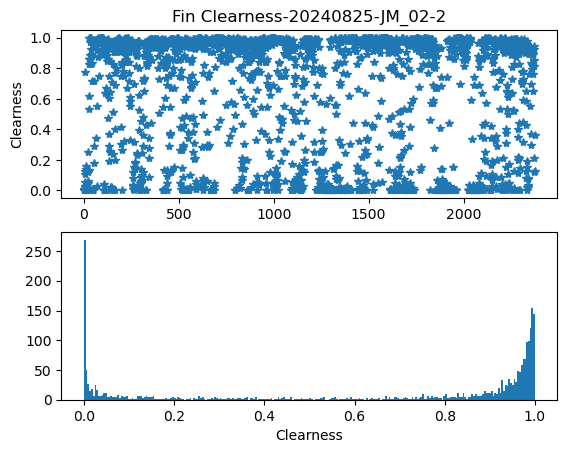

In [21]:
plt.subplot(2, 1, 1)
plt.title("Fin Clearness-"+dataset_name)
plt.plot(fin_dataset.clearness, "*")
plt.ylabel("Clearness")
plt.subplot(2, 1, 2)
plt.hist(fin_dataset.clearness, bins=256)
plt.xlabel("Clearness")
plt.savefig(root_dir + "/METAINFO/FinClearness.png")
plt.show()